# Create a custom figure in the notebook

This example defines a small plotting class directly in the notebook and uses it on the output of a pipeline run.


## Bootstrap project imports


In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = None
for candidate in (NOTEBOOK_DIR, *NOTEBOOK_DIR.parents):
    if (candidate / "src").exists() and (candidate / "notebooks").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate reco_algorithm_tests project root.")

src_dir = PROJECT_ROOT / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

print(f"Project root: {PROJECT_ROOT}")


Project root: /workdir/playground/reco_algorithm_tests


## Import pipeline and plotting tools


In [2]:
import matplotlib.pyplot as plt

from algorithms import DefaultTrackletFormer
from data_io import RecoDataFile, load_pioneer_libraries
from figures import PlotFigure
from pipeline.pipeline import Pipeline
from pipeline.stages import EventInitStage, EventInputStage, InputContext, TrackletStage


## Load PIONEER libraries and the smoke-test data


In [3]:
load_pioneer_libraries()

DATA_PATH = PROJECT_ROOT / ".data" / "current" / "all_rec.root"
ENTRY_INDEX = 0

reco_data = RecoDataFile(str(DATA_PATH))
print(f"Loaded data file: {DATA_PATH}")
print(f"Entries available: {reco_data.entries}")


Loaded data file: /workdir/playground/reco_algorithm_tests/.data/current/all_rec.root
Entries available: 727


## Define a new figure inline

This one just compares front-side and back-side ATAR hit counts for a single event.


In [4]:
class FrontBackHitCountFigure(PlotFigure):
    def draw(self, event):
        front_hits = sum(hit.detector_side == "front" for hit in event.all_hits)
        back_hits = sum(hit.detector_side == "back" for hit in event.all_hits)

        fig, ax = plt.subplots(figsize=(6.0, 4.0), constrained_layout=True)
        labels = ["front", "back"]
        values = [front_hits, back_hits]
        bars = ax.bar(labels, values, color=["tab:blue", "tab:orange"])

        for bar, value in zip(bars, values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                value,
                str(value),
                ha="center",
                va="bottom",
            )

        ax.set_ylabel("ATAR hits")
        ax.set_title(f"Event {event.event_id}: front/back hit counts")
        self._display(plt)
        return fig, ax


## Run a small pipeline and draw the figure


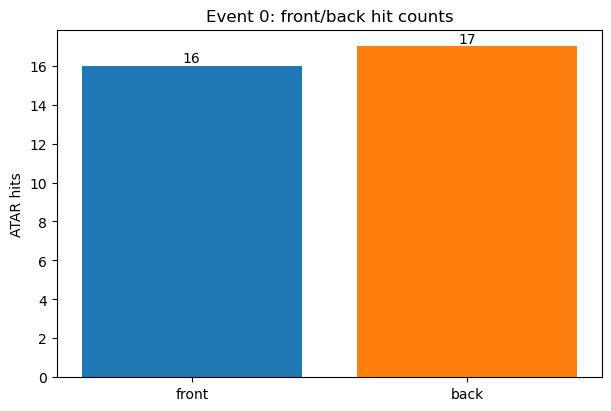

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Event 0: front/back hit counts'}, ylabel='ATAR hits'>)

In [5]:
pipeline = Pipeline()
pipeline.register_stage(EventInputStage())
pipeline.register_stage(EventInitStage())
pipeline.register_stage(TrackletStage(DefaultTrackletFormer()))

pipeline.run(InputContext(reco_data, ENTRY_INDEX))
event = pipeline.get_event()

figure = FrontBackHitCountFigure(show=True)
figure.draw(event)
